# Exploratory Data Analysis for New York Taxi Dataset
1. Read nyc 2022 data
2. Organize it into number of arrivals and number of departures by location for each hour format
3. Organize it into a tensor
4. Generate similarity graph for locations
5. Run LR-STSS on it
6. Visualize it on a map 

Make an interactive dashboard with it

In [1]:
import sys
import os

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import networkx as nx
from scipy import io
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
# from IPython.display import display, HTML

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# from src.gsp.gsp_vis import draw_graph_signal
# from src.gsp.incidence_tensor import full_incidence_matrix
from src.proximal_ops.prox_overlapping_grouped_l21 import group_indicator_matrix

In [2]:
%load_ext autoreload
%autoreload 2
from src.models.lr_stss.lr_ssd import LR_SSD, MetricTracker
from src.models.lr_ssd.lr_logs import LR_LOGS
from src.models.lr_ssd.lr_logs_st_tf import LR_LOGS_ST_TF
from src.models.lr_ssd.snn_logs import SNN_LOGS 
# from experiment_board.NYC_dataset_exps.nyc_lr_ssd_utility_functions import *

### Load Data

In [3]:
# Load pre-processed Data
cwd = os.getcwd()
data_dir = os.path.join(cwd,'..','..','data','nyc_taxi_data')

zones = gpd.read_file(os.path.join(data_dir,'taxi_zones_shapefile','taxi_zones.shp'))
zone_lookup = os.path.join(data_dir, 'taxi_zone_lookup.csv')
zone_lookup = pd.read_csv(zone_lookup)
# # Load Emre's settings
dates = io.loadmat(os.path.join(data_dir,'dates.mat'))
regions = io.loadmat(os.path.join(data_dir,'regions.mat'))
neighbors = io.loadmat(os.path.join(data_dir,'neighbors.mat'))
regions=regions['regions'].ravel()
zones = zones.iloc[regions-1]
zones2 = zones.reset_index()
arrivals = io.loadmat('arrivals.mat')['Y']
dropoffs = np.moveaxis(arrivals,[0,1,2,3],[3,2,1,0])
dropoffs.shape

(81, 53, 7, 24)

## Create Graph

Number of edges: 208, Number of line graph edges: 961, Gt n of edges: 23


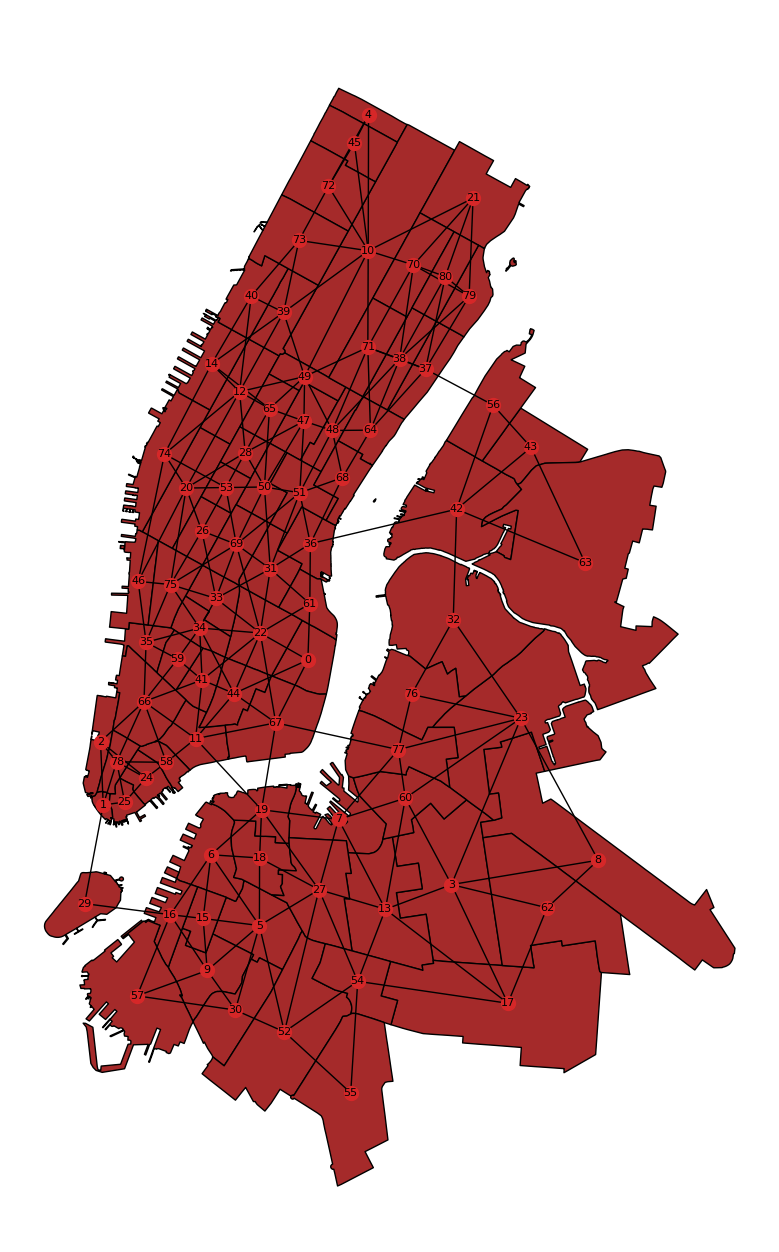

In [4]:
pos = np.zeros((81,2))
pos[:,0] = zones.geometry.centroid.x.values
pos[:,1] = zones.geometry.centroid.y.values
edge_list = nx.from_scipy_sparse_array( kneighbors_graph(pos, 2, mode='connectivity', include_self=False)).edges()

adjacency_list = []
for index, polygon in zones2.iterrows():
    for other_index, other_polygon in zones2.iterrows():
        if index != other_index and polygon.geometry.intersects(other_polygon.geometry.buffer(1)):
            adjacency_list.append((index, other_index))

G_nyc = nx.Graph()
G_nyc.add_nodes_from(range(81))
G_nyc.add_edges_from(adjacency_list)
G_nyc.add_edges_from([(11,19), (36,42), (67,77), (19,67)])
G_nyc.add_edges_from(edge_list)
# G_nyc =nx.DiGraph(G_nyc)
LG = nx.line_graph(G_nyc)
# LG = nx.DiGraph(LG)

# fig, axe = draw_graph_signal(G_nyc, np.ones(81), pos=pos, suptitle='NYC Taxi Zones', node_size=100, cmap='viridis', figsize=(6,6))
fig, ax = plt.subplots(1,1, figsize=(10,16));
zones.geometry.buffer(-100).plot(ax = ax)
Gt = nx.path_graph(24)
print(f"Number of edges: {G_nyc.number_of_edges()}, Number of line graph edges: {LG.number_of_edges()}, Gt n of edges: {Gt.number_of_edges()}")
# draw_graph_signal(LG, np.ones(len(LG.nodes())), suptitle='NYC Taxi Zones', node_size=100, cmap='viridis', figsize=(6,6))
zones2.plot(ax=ax, color='brown', edgecolor='black');
nx.draw(G_nyc, pos={list(G_nyc)[i]: pos[i,:] for i in range(len(G_nyc))}, ax=ax, 
        node_size=100, edge_color='black', with_labels=True, node_color='C3',  font_size=8);
# zones2.plot()

In [8]:
dtype = torch.float64
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
Y = torch.tensor(dropoffs, dtype=dtype, device=device)
# G_ind, w1 = group_indicator_matrix(G_nyc, grouping='neighbor', weighing='size_normalized', device='cpu')
# G_ind = G_ind.to(device=device, dtype=dtype)
# w1 = w1.to(device=device, dtype=dtype)
# # G_ind2 = #G_ind.clone().detach().t().to_sparse_csr()

# G_ind_coo = G_ind.to_sparse_coo();
# G_ind_T = G_ind.clone().detach().t().to_sparse_csc(); 
# B = nx.incidence_matrix(G_nyc, oriented=True)
# B1 = torch.sparse_csr_tensor(B.indptr, B.indices, B.data, device=device, dtype=dtype)
# B = nx.incidence_matrix(LG, oriented=True)
# B2 = torch.sparse_csr_tensor(B.indptr, B.indices, B.data, device=device, dtype=dtype)
# B2 = B1.t()@B2.t().to_sparse_csr()
# B1 = B1.t().to_sparse_csr()
# B = nx.incidence_matrix(Gt, oriented=True)
# Bt = torch.sparse_csr_tensor(B.indptr, B.indices, B.data, device=device, dtype=dtype).t().to_sparse_csr()

# G_ind2 = B1.clone().detach().to_sparse_csr()
# G_ind2_coo = G_ind2.to_sparse_coo()
# G_ind2_T = G_ind2.clone().detach().t().to_sparse_csc()
# w2 = torch.sum(G_ind2, dim=1, keepdim=True)


In [5]:
from functools import partial
from pprint import pprint

import optuna
from dask.distributed import Client, wait
# from data.nyc_taxi_data.

n_cores = 4
client = Client(n_workers=n_cores)
client

print("Is cuda available?\t",torch.cuda.is_available())
print("How many cuda cores are available?\t",torch.cuda.device_count())

maxit = 100
err_tol = 1e-5
ALGORITHMS = ['LR_LOGS', 'LR_LOGS_ST_TF'] #'Trend', 'Aniso_Trend', 'Grouped_Aniso', 'Aniso_Trend', 'Grouped_Aniso_Trend']
PERCENTAGES = ['3.0%','2.0%','1.0%','0.7%','0.3%','0.14%','0.07%','0.014%']


def detect_topk_events(anomaly_scores, ratio):
    events_start_ts = pd.to_datetime(['01-Jan-2018', '03-Jan-2018 16:00:00', '14-Jan-2018 09:00:00', '20-Jan-2018 08:00:00', 
                                    '4-Mar-2018 15:00:00', '08-Mar-2018 18:00:00', '17-Mar-2018 11:00:00', '20-Mar-2018 10:00:00',
                                    '21-Mar-2018 16:00:00', '01-Jul-2018 17:00:00', '04-Jul-2018 17:00:00', '25-Sep-2018 10:00:00',
                                    '04-Oct-2018 08:00:00', '04-Nov-2018 12:00:00', '09-Nov-2018 19:00:00', '22-Nov-2018 21:00:00',
                                    '4-Dec-2018 19:00:00', '16-Dec-2018 10:00:00', '28-Dec-2018 12:00:00', '31-Dec-2018 21:00:00',
                                    ], format='mixed')
    events_end_ts = pd.to_datetime(['01-Jan-2018 02:00:00', '03-Jan-2018 22:00:00', '14-Jan-2018 17:00:00', '20-Jan-2018 15:00:00',
                             '4-Mar-2018 22:00:00', '08-Mar-2018 23:59:00', '17-Mar-2018 17:00:00', '20-Mar-2018 20:00:00',
                            '21-Mar-2018 22:00:00', '01-Jul-2018 22:00:00', '04-Jul-2018 23:00:00', '25-Sep-2018 20:00:00',
                            '04-Oct-2018 15:00:00', '04-Nov-2018 17:00:00', '09-Nov-2018 23:30:00', '22-Nov-2018 23:59:00',
                            '4-Dec-2018 23:59:00', '16-Dec-2018 15:00:00', '28-Dec-2018 17:00:00', '31-Dec-2018 23:59:00'
                                ], format='mixed')
    indd = np.flip(np.argsort(anomaly_scores, axis=None))
    ind = np.unravel_index(indd[:int(len(indd)*ratio)], anomaly_scores.shape)
    topk_event_idx = ind
    anomaly_mask = np.zeros(anomaly_scores.shape, dtype=bool)
    anomaly_mask[topk_event_idx] =1
#     num_detected_events = 0
    detected_events = np.zeros(20)

    idxs = np.arange(81)
    # w = events_start_ts.isocalendar().week
    # d = events_start_ts.day_of_week
    doy = events_start_ts.day_of_year
    w = (doy-1)//(7)
    d = (doy-1) % 7
    h_s = events_start_ts.hour
    h_e = events_end_ts.hour
    for i in range(20):
        event_mask = np.zeros(anomaly_scores.shape, dtype=bool)
        locations = dates['dates'][2].ravel()[i].ravel()
        
        for loc in locations: 
            # event_mask[idxs[regions==loc], w[i]-1, d[i], h_s[i]:h_e[i]] = 1
            # event_mask[idxs[regions==loc], w[i]-1, d[i], h_e[i]] = 1
            event_mask[idxs[regions==loc], w[i], d[i], h_s[i]:h_e[i]] = 1
            event_mask[idxs[regions==loc], w[i], d[i], h_e[i]] = 1
        if np.any(event_mask * anomaly_mask):
#             num_detected_events +=1
            detected_events[i]=1
    return detected_events#num_detected_events

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)  # old winner trial if exists
    best_trial = max(study.best_trials, key= lambda t: t.values[0])
    if study.best_trials and winner != best_trial.values:
        study.set_user_attr("winner", best_trial.values)
        if winner:
            print(f"Algorithm: {frozen_trial.user_attrs['algorithm']}\t Trial {frozen_trial.number} achieved value: {frozen_trial.values}.")
            pprint([frozen_trial.user_attrs[pcntg] for pcntg in PERCENTAGES])
            pprint(frozen_trial.user_attrs['metrics'])
            pprint(frozen_trial.params)
        else:
            print(f"Algorithm: {frozen_trial.user_attrs['algorithm']}\t Trial {frozen_trial.number} achieved value: {frozen_trial.values}.")
            pprint([frozen_trial.user_attrs[pcntg] for pcntg in PERCENTAGES])
            pprint(frozen_trial.user_attrs['metrics'])
            pprint(frozen_trial.params)

2025-02-06 10:17:36,861 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-w2wb691q', purging
2025-02-06 10:17:36,862 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-x23863dh', purging
2025-02-06 10:17:36,862 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-j1051u1j', purging
2025-02-06 10:17:36,862 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-_1z0ajkp', purging


Is cuda available?	 True
How many cuda cores are available?	 4


In [ ]:
device = 'cuda:2'
dtype = torch.float64

def horpca_bic_obj(trial, grouping='neighbor', weighing='size_normalized_inv'):
    alg_params = {#'lda_f': trial.suggest_float('lda_f', 1e-2, 1e4, log=True),
                'lda': trial.suggest_float('lda', 1e-5, 1e1, log=True),
                'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                'psis': [trial.suggest_float('psi_1', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_2', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_3', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_4', 1e-4, 1e2, log=True)],
                'max_iter':maxit,
                'err_tol':err_tol,
                }
    
    snn_logn = SNN_LOGS(Y, G_nyc, lr_modes=[1,2,3,4], graph_modes=[1], 
                       grouping=grouping, weighing=weighing,
                  device=device, dtype=dtype, verbose=0)
    X, S = snn_logn(**alg_params)

    metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
            'converged': snn_logn.converged*1, 
            'iterations': snn_logn.it, 
            'primal_residual': snn_logn.r[-1].cpu().numpy(), 
            'dual_residual': snn_logn.s[-1].cpu().numpy(),
            'time': sum(snn_logn.times['iteration'])}

    alg_name = 'SNN_LOGN('
    alg_name += 'N)' if grouping=='neighbor' else 'E)'
    trial.set_user_attr('algorithm', alg_name)
    trial.set_user_attr('metrics', metrics)
    trial.set_user_attr('grouping', grouping)
    trial.set_user_attr('weighing', weighing)
    abs_s = np.abs(S.cpu().detach().numpy())
    ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
    num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
    for i, pcntg in enumerate(PERCENTAGES):
        trial.set_user_attr(pcntg, num_detected_events[i])
    return sum(num_detected_events), num_detected_events[-1]

In [9]:
device = 'cuda:2'
dtype = torch.float64
G_ind_n, w_sn = group_indicator_matrix(G_nyc, grouping='neighbor', weighing='size_normalized', device='cpu')
G_ind_e, w_se = group_indicator_matrix(G_nyc, grouping='edge', weighing='size_normalized', device='cpu')
w_sn = w_sn.to(device=device, dtype=dtype)
w_se = w_se.to(device=device, dtype=dtype)
groupings = {'neighbor': {'G_ind': G_ind_n.to_sparse_coo().to(device=device, dtype=dtype),
                          'size_normalized': w_sn.to_dense(),
                          'size_normalized_inv': 1/w_sn.to_dense(),
                          'uniform': torch.ones_like(w_sn.to_dense())},
             'edge': {'G_ind': G_ind_e.to_sparse_coo().to(device=device, dtype=dtype),
                      'size_normalized': w_se.to_dense(),
                      'size_normalized_inv': 1/w_se.to_dense(),
                      'uniform': torch.ones_like(w_se.to_dense())}
           }
def lr_logs_obj(trial, grouping='neighbor', weighing='size_normalized'):
    alg_params = {'lda_f': trial.suggest_float('lda_f', 1e-2, 1e4, log=True),
                'lda_0': trial.suggest_float('lda_0', 1e-5, 1e1, log=True),
                'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                'psis': [trial.suggest_float('psi_1', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_2', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_3', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_4', 1e-4, 1e2, log=True)],
                'max_iter':maxit,
                'err_tol':err_tol,
                }
    
    G_ind_coo = groupings[grouping]['G_ind']
    weights = groupings[grouping][weighing]
    lr_logs = LR_LOGS(Y, G_ind_coo, weights, lr_modes=[1,2,3,4], graph_modes=[1], 
                  device=device, dtype=dtype, verbose=0)
    X, S = lr_logs(**alg_params)

    metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
            'converged': lr_logs.converged*1, 
            'iterations': lr_logs.it, 
            'primal_residual': lr_logs.r[-1].cpu().numpy(), 
            'dual_residual': lr_logs.s[-1].cpu().numpy(),
            'time': sum(lr_logs.times['iteration'])}

    trial.set_user_attr('algorithm', 'LR_LOGS')
    trial.set_user_attr('metrics', metrics)
    trial.set_user_attr('grouping', grouping)
    trial.set_user_attr('weighing', weighing)
    abs_s = np.abs(S.cpu().detach().numpy())
    ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
    num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
    for i, pcntg in enumerate(PERCENTAGES):
        trial.set_user_attr(pcntg, num_detected_events[i])
    return sum(num_detected_events), num_detected_events[-1]

def snn_logn_obj(trial, grouping='neighbor', weighing='size_normalized_inv'):
    alg_params = {#'lda_f': trial.suggest_float('lda_f', 1e-2, 1e4, log=True),
                'lda': trial.suggest_float('lda', 1e-5, 1e1, log=True),
                'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                'psis': [trial.suggest_float('psi_1', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_2', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_3', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_4', 1e-4, 1e2, log=True)],
                'max_iter':maxit,
                'err_tol':err_tol,
                }
    
    snn_logn = SNN_LOGS(Y, G_nyc, lr_modes=[1,2,3,4], graph_modes=[1], 
                       grouping=grouping, weighing=weighing,
                  device=device, dtype=dtype, verbose=0)
    X, S = snn_logn(**alg_params)

    metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
            'converged': snn_logn.converged*1, 
            'iterations': snn_logn.it, 
            'primal_residual': snn_logn.r[-1].cpu().numpy(), 
            'dual_residual': snn_logn.s[-1].cpu().numpy(),
            'time': sum(snn_logn.times['iteration'])}

    alg_name = 'SNN_LOGN('
    alg_name += 'N)' if grouping=='neighbor' else 'E)'
    trial.set_user_attr('algorithm', alg_name)
    trial.set_user_attr('metrics', metrics)
    trial.set_user_attr('grouping', grouping)
    trial.set_user_attr('weighing', weighing)
    abs_s = np.abs(S.cpu().detach().numpy())
    ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
    num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
    for i, pcntg in enumerate(PERCENTAGES):
        trial.set_user_attr(pcntg, num_detected_events[i])
    return sum(num_detected_events), num_detected_events[-1]

In [10]:
objective = partial(snn_logn_obj, grouping='edge', weighing='size_normalized_inv')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: SNN_LOGN(E)	 Trial 0 achieved value: [5.0, 2.0].
[0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 2.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.10051317),
 'iterations': 100,
 'primal_residual': array(6.32555755),
 'time': 10.554579147137702}
{'lda': 0.9441765076690674,
 'psi_1': 0.023523812439892308,
 'psi_2': 0.00010975738926873778,
 'psi_3': 0.1288922483353432,
 'psi_4': 0.02692749760248494,
 'rho': 1.2936721798166973e-05}
Algorithm: SNN_LOGN(E)	 Trial 1 achieved value: [22.0, 8.0].
[0.0, 0.0, 2.0, 2.0, 2.0, 2.0, 6.0, 8.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(4.72055581),
 'iterations': 100,
 'primal_residual': array(314.22942981),
 'time': 8.770591211505234}
{'lda': 0.1905446063212161,
 'psi_1': 0.0010892538963541574,
 'psi_2': 0.0006119383595196537,
 'psi_3': 1.8769480231968692,
 'psi_4': 24.116532689510393,
 'rho': 0.0020532316973240917}
Algorithm: SNN_LOGN(E)	 Trial 3 achieved value: [26.0, 9.0].
[0.0, 0.0, 2.0, 2.0, 2.0, 4.0, 7.0, 9.0]
{'

In [18]:
objective = partial(snn_logn_obj, grouping='neighbor', weighing='size_normalized_inv')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: alg_name	 Trial 0 achieved value: [21.0, 8.0].
[0.0, 0.0, 1.0, 2.0, 2.0, 2.0, 6.0, 8.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.27953231),
 'iterations': 100,
 'primal_residual': array(27.86764214),
 'time': 9.516741094179451}
{'lda': 0.01460258208208311,
 'psi_1': 0.001831655741807773,
 'psi_2': 0.00010754827374541752,
 'psi_3': 0.3816028025048236,
 'psi_4': 24.379771179429763,
 'rho': 7.061738153946215e-05}
Algorithm: alg_name	 Trial 1 achieved value: [26.0, 9.0].
[0.0, 0.0, 2.0, 2.0, 2.0, 4.0, 7.0, 9.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.06209148),
 'iterations': 100,
 'primal_residual': array(5.21259185),
 'time': 9.549067810177803}
{'lda': 9.9342088786979e-05,
 'psi_1': 0.0017166751748952554,
 'psi_2': 0.006953544917964112,
 'psi_3': 0.0006188447095589164,
 'psi_4': 0.049019171738353004,
 'rho': 1.9972535230512266e-05}
Algorithm: alg_name	 Trial 34 achieved value: [54.0, 16.0].
[0.0, 1.0, 1.0, 3.0, 8.0, 11.0, 14.0, 16.0]
{'

In [31]:
objective = partial(lr_logs_obj, grouping='neighbor', weighing='size_normalized')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])


Algorithm: LR_LOGS	 Trial 0 achieved value: [30.0, 10.0].
[0.0, 1.0, 2.0, 2.0, 3.0, 4.0, 8.0, 10.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(10.00050056),
 'iterations': 100,
 'primal_residual': array(123842.28239952),
 'time': 1.9448231812566519}
{'lda_0': 0.0037639489573877845,
 'lda_f': 0.025067762898619946,
 'psi_1': 0.0009560282516210727,
 'psi_2': 36.54991652405241,
 'psi_3': 0.007617044372116953,
 'psi_4': 0.034633516316737785,
 'rho': 3.1891736878977795e-05}
Algorithm: LR_LOGS	 Trial 1 achieved value: [62.0, 14.0].
[0.0, 2.0, 5.0, 8.0, 9.0, 11.0, 13.0, 14.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(7.68308927e-06),
 'iterations': 100,
 'primal_residual': array(6.379042),
 'time': 1.9137349547818303}
{'lda_0': 0.0022893198129897256,
 'lda_f': 21.416928362936424,
 'psi_1': 0.0018553475256853696,
 'psi_2': 0.00026930364015013335,
 'psi_3': 0.0005651479864221706,
 'psi_4': 0.2610627410565811,
 'rho': 2.656601593062318e-05}
Algorithm: LR_LOGS	 Tri

In [32]:
objective = partial(lr_logs_obj, grouping='edge', weighing='size_normalized')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])


Algorithm: LR_LOGS	 Trial 0 achieved value: [25.0, 9.0].
[0.0, 0.0, 1.0, 2.0, 2.0, 4.0, 7.0, 9.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(1.57402329),
 'iterations': 100,
 'primal_residual': array(1472.24237842),
 'time': 1.9828637233003974}
{'lda_0': 2.6084200737363505,
 'lda_f': 488.5194434035805,
 'psi_1': 0.03576344533230716,
 'psi_2': 0.0009804089964476615,
 'psi_3': 0.0033191840729545645,
 'psi_4': 67.52260506569775,
 'rho': 1.0496860690525982}
Algorithm: LR_LOGS	 Trial 1 achieved value: [33.0, 10.0].
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 10.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.00956158),
 'iterations': 100,
 'primal_residual': array(205.98837945),
 'time': 1.9284134693443775}
{'lda_0': 0.7164172566195115,
 'lda_f': 72.189427629049,
 'psi_1': 1.2478877940971125,
 'psi_2': 1.1413377343803122,
 'psi_3': 0.00012820750111346762,
 'psi_4': 0.08910630982852202,
 'rho': 0.019929360548746316}
Algorithm: LR_LOGS	 Trial 2 achieved value: [79.0, 1

In [33]:
objective = partial(lr_logs_obj, grouping='neighbor', weighing='size_normalized_inv')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: LR_LOGS	 Trial 0 achieved value: [17.0, 6.0].
[1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 3.0, 6.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(320.15901257),
 'iterations': 100,
 'primal_residual': array(6576.9501274),
 'time': 1.9946920117363334}
{'lda_0': 0.10096486742882384,
 'lda_f': 0.01652964459029986,
 'psi_1': 1.326178095438407,
 'psi_2': 71.46955583154369,
 'psi_3': 0.18083662358862718,
 'psi_4': 0.6635256498322366,
 'rho': 0.2778470881101548}
Algorithm: LR_LOGS	 Trial 1 achieved value: [32.0, 9.0].
[0.0, 1.0, 1.0, 3.0, 4.0, 5.0, 9.0, 9.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.04896973),
 'iterations': 100,
 'primal_residual': array(40.57298829),
 'time': 1.918632979504764}
{'lda_0': 0.027781462097936856,
 'lda_f': 7477.186451057805,
 'psi_1': 83.90347235285124,
 'psi_2': 1.808479145411926,
 'psi_3': 0.08294767580890916,
 'psi_4': 0.5393341338780339,
 'rho': 0.385318792123795}
Algorithm: LR_LOGS	 Trial 2 achieved value: [96.0, 19.0].
[3.0, 

In [32]:
G_ind_coo = groupings['neighbor']['G_ind']
lr_logs_st_tf = LR_LOGS_ST_TF(Y, G_ind_coo, w1.to_dense(), B1.t(), B2.t(), Bt.t(),
                            lr_modes=[1,2,3,4], graph_modes=[1], temporal_mode=4,
                                 device=device, dtype=dtype, verbose=0)

x, s = lr_logs_st_tf(lda_f=100, lda_0=1e-2, lda_1=1e-3, lda_2=1e-3, lda_t=1e-3,
                     rho=1e-3, 
                     psis=[1, 1, 1, 1], max_iter=100, err_tol=1e-5)

abs_s = np.abs(s.cpu().detach().numpy())
ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
print(num_detected_events)

[ 3.  4.  6.  8. 13. 13. 17. 18.]


In [35]:
device = 'cuda:1'
dtype = torch.float64
G_ind_n, w_sn = group_indicator_matrix(G_nyc, grouping='neighbor', weighing='size_normalized', device='cpu')
G_ind_e, w_se = group_indicator_matrix(G_nyc, grouping='edge', weighing='size_normalized', device='cpu')
w_sn = w_sn.to(device=device, dtype=dtype)
w_se = w_se.to(device=device, dtype=dtype)
groupings = {'neighbor': {'G_ind': G_ind_n.to_sparse_coo().to(device=device, dtype=dtype),
                          'size_normalized': w_sn.to_dense(),
                          'size_normalized_inv': 1/w_sn.to_dense(),
                          'uniform': torch.ones_like(w_sn.to_dense())},
             'edge': {'G_ind': G_ind_e.to_sparse_coo().to(device=device, dtype=dtype),
                      'size_normalized': w_se.to_dense(),
                      'size_normalized_inv': 1/w_se.to_dense(),
                      'uniform': torch.ones_like(w_se.to_dense())}
           }
def lr_logs_st_tf_obj(trial, grouping='neighbor', weighing='size_normalized'):
    alg_params = {'lda_f': trial.suggest_float('lda_f', 1e-2, 1e4, log=True),
                'lda_0': trial.suggest_float('lda_0', 1e-5, 1e1, log=True),
                'lda_1': trial.suggest_float('lda_1', 1e-5, 1e1, log=True),
                'lda_2': trial.suggest_float('lda_2', 1e-5, 1e1, log=True),
                'lda_t': trial.suggest_float('lda_t', 1e-5, 1e1, log=True),
                'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                'psis': [trial.suggest_float('psi_1', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_2', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_3', 1e-4, 1e2, log=True),
                        trial.suggest_float('psi_4', 1e-4, 1e2, log=True)],
                'max_iter':maxit,
                'err_tol':err_tol,
                }
    
    G_ind_coo = groupings[grouping]['G_ind']
    weights = groupings[grouping][weighing]
    lr_logs_st_tf = LR_LOGS_ST_TF(Y, G_ind_coo, weights, B1.t(), B2.t(), Bt.t(),
                            lr_modes=[1,2,3,4], graph_modes=[1], temporal_mode=4,
                                 device=device, dtype=dtype, verbose=0)

    X, S = lr_logs_st_tf(**alg_params)

    metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
            'converged': lr_logs_st_tf.converged*1, 
            'iterations': lr_logs_st_tf.it, 
            'primal_residual': lr_logs_st_tf.r[-1].cpu().numpy(), 
            'dual_residual': lr_logs_st_tf.s[-1].cpu().numpy(),
            'time': sum(lr_logs_st_tf.times['iteration'])}

    trial.set_user_attr('algorithm', 'LR_LOGS')
    trial.set_user_attr('metrics', metrics)
    trial.set_user_attr('grouping', grouping)
    trial.set_user_attr('weighing', weighing)
    abs_s = np.abs(S.cpu().detach().numpy())
    ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
    num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
    for i, pcntg in enumerate(PERCENTAGES):
        trial.set_user_attr(pcntg, num_detected_events[i])
    return sum(num_detected_events), num_detected_events[-1]

In [36]:
objective = partial(lr_logs_st_tf_obj, grouping='neighbor', weighing='size_normalized_inv')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: LR_LOGS	 Trial 0 achieved value: [89.0, 20.0].
[1.0, 3.0, 7.0, 11.0, 13.0, 15.0, 19.0, 20.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(9.64655957),
 'iterations': 100,
 'primal_residual': array(664414.80994434),
 'time': 0}
{'lda_0': 1.3457138736682352,
 'lda_1': 0.03443019614036068,
 'lda_2': 0.013246940817861146,
 'lda_f': 0.016629113120105298,
 'lda_t': 0.07612673987408036,
 'psi_1': 98.74390383456486,
 'psi_2': 0.0004988776271383642,
 'psi_3': 3.8611086224598377,
 'psi_4': 0.0024096383230888933,
 'rho': 0.00019089684721671654}
Algorithm: LR_LOGS	 Trial 5 achieved value: [99.0, 19.0].
[3.0, 8.0, 10.0, 12.0, 14.0, 15.0, 18.0, 19.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.00052343),
 'iterations': 100,
 'primal_residual': array(17.93819589),
 'time': 0}
{'lda_0': 0.0001671734353444677,
 'lda_1': 0.00016228145249740436,
 'lda_2': 0.9418522851142691,
 'lda_f': 3169.0162402735323,
 'lda_t': 3.845910908928408e-05,
 'psi_1': 0.00194371674769

In [37]:
objective = partial(lr_logs_st_tf_obj, grouping='edge', weighing='size_normalized_inv')

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: LR_LOGS	 Trial 0 achieved value: [8.0, 4.0].
[0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 4.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(5.15982752),
 'iterations': 100,
 'primal_residual': array(30875.73088834),
 'time': 0}
{'lda_0': 0.5068740020425377,
 'lda_1': 0.0001872830777508105,
 'lda_2': 0.000740664786554946,
 'lda_f': 0.07866102760892726,
 'lda_t': 0.023783789277931316,
 'psi_1': 0.0003289830310606742,
 'psi_2': 0.17893612821494306,
 'psi_3': 0.0002121405989539522,
 'psi_4': 0.1322737441930215,
 'rho': 0.00011327108125206628}
Algorithm: LR_LOGS	 Trial 1 achieved value: [56.0, 13.0].
[1.0, 2.0, 4.0, 7.0, 8.0, 9.0, 12.0, 13.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.02377438),
 'iterations': 100,
 'primal_residual': array(71.50191135),
 'time': 0}
{'lda_0': 0.0021162677498531334,
 'lda_1': 2.9848798394204854,
 'lda_2': 0.0007852511226384001,
 'lda_f': 180.46089702915276,
 'lda_t': 3.407263471326666e-05,
 'psi_1': 0.002336176800224459,
 'p

In [7]:
psis = torch.tensor([0.82952326, 1, 0.36393996, 0.63633344], device=device, dtype=dtype)
# psi =  6.330030868935934 # 12.83335528216673 # 32# final: psi = 6.330030868935934
# lda_l = 52.4203154644308 # 6.386243343144918 # 56#      lda_l = 
# lda_1 = 381.5726253552148 # 471.62025607182056 # 48#.
# lda_t = 0.05662389826485177 # 251.84760832599633# 100 #
# rho = 2.8422507662618838e-5 # 5.4622401816620816e-5 # 0.0005 #
# lda_2 = 1000
lr_ssd = LR_SSD(Y, B1, B2, Bt, lr_modes=[1,2,3,4], time_mode=4, graph_modes=[1],
                G_ind=[G_ind, G_ind2], G_ind_coo=[G_ind_coo, G_ind2_coo], G_ind_T=[G_ind_T, G_ind2_T],
                group_weights=[w1,w2], rho_update_thr=80)

lr_ssd(rho=2.84225e-5, max_iter=150, psis=6.330030868935934 *psis,
        lda_f=1000, lda_0=0, lda_g0=0.1, lda_1=0.001, lda_g1=0, lda_2=1, lda_t=0.0566);
print(f"Num detected events: {np.sum(detect_topk_events(np.abs(lr_ssd.S.cpu().detach().numpy()), 0.03))}")

Converged at iteration 1 with duality gap 0.0000E+00
It-0   	## |r| = 3.096e+05   	## |s| = 8.800e+00
|r_Xi_0| = 1.793e+05  	##|s_Xi_0| = 5.097e+00  	## rho_Xi_0 = 2.842e-05
|r_Xi_1| = 1.793e+05  	##|s_Xi_1| = 5.097e+00  	## rho_Xi_1 = 2.842e-05
|r_Xi_2| = 9.117e+04  	##|s_Xi_2| = 2.591e+00  	## rho_Xi_2 = 2.842e-05
|r_Xi_3| = 1.524e+05  	##|s_Xi_3| = 4.333e+00  	## rho_Xi_3 = 2.842e-05
|r_S0| = 2.039e-02  	##|s_S0| = 5.794e-07  	## rho_S0 = 2.842e-05
|r_W1| = 2.231e-02  	##|s_W1| = 6.340e-07  	## rho_W1 = 2.842e-05
|r_W2| = 6.531e-02  	##|s_W2| = 1.856e-06  	## rho_W2 = 2.842e-05
|r_St| = 2.091e-02  	##|s_St| = 5.794e-07  	## rho_St = 2.842e-05
Gap 1: 0.000e+00  	## Gap 2: 0.000e+00
Converged at iteration 1 with duality gap 0.0000E+00
It-1   	## |r| = 1.014e+05   	## |s| = 3.169e+00
|r_Xi_0| = 5.391e+04  	##|s_Xi_0| = 1.685e+00  	## rho_Xi_0 = 3.126e-05
|r_Xi_1| = 4.971e+04  	##|s_Xi_1| = 1.554e+00  	## rho_Xi_1 = 3.126e-05
|r_Xi_2| = 4.173e+04  	##|s_Xi_2| = 1.305e+00  	## rho_Xi_2 =

KeyboardInterrupt: 

In [15]:


def objective_f(trial, algo='Trend', B1_=B1, B2_=B2, Bt_=Bt, G_ind_=[G_ind, G_ind2], G_ind_coo_=[G_ind_coo, G_ind2_coo], G_ind_T_=[G_ind_T, G_ind2_T]):
    if algo == 'Aniso_Trend':
        alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                        'lda_0': trial.suggest_float('lda_0', 1e-4, 1e3, log=True),
                        'lda_g0': 0,
                        'lda_1': trial.suggest_float('lda_1', 1e-4, 1e3, log=True),
                        'lda_g1': 0,
                        'lda_2' : trial.suggest_float('lda_2', 1e-4, 1e3, log=True),
                        'lda_t' : trial.suggest_float('lda_t', 1e-4, 1e3, log=True),
                        'lda_f': 1000,
                        'rho': trial.suggest_float('rho', 1e-4, 1e3, log=True),
                        'max_iter': maxit,
                        }
    elif algo == 'Trend':
        alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                        'lda_0': trial.suggest_float('lda_0', 1e-4, 1e3, log=True),
                        'lda_g0': 0,
                        'lda_1': 0,
                        'lda_g1': 0,
                        'lda_2' : trial.suggest_float('lda_2', 1e-4, 1e3, log=True),
                        'lda_t' : trial.suggest_float('lda_t', 1e-4, 1e3, log=True),
                        'lda_f': 1000,
                        'rho': trial.suggest_float('rho', 1e-4, 1e3, log=True),
                        'max_iter': maxit,
                        }
    elif algo == 'Aniso':
        alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                        'lda_0': trial.suggest_float('lda_0', 1e-5, 1.0, log=True),
                        'lda_g0': 0,
                        'lda_1': trial.suggest_float('lda_1', 1e-5, 1.0, log=True),
                        'lda_g1': 0,
                        'lda_2' : 0,
                        'lda_t' : trial.suggest_float('lda_t', 1e-5, 1.0, log=True),
                        'lda_f': 1000,
                        'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                        'max_iter': maxit,
                        }
    elif algo == 'Grouped_Aniso_Trend':
        alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-1, 1e2, log=True),
                                trial.suggest_float('psi_2', 1e-1, 1e2, log=True),
                                trial.suggest_float('psi_3', 1e-1, 1e2, log=True),
                                trial.suggest_float('psi_4', 1e-1, 1e2, log=True)],
                        'lda_0': trial.suggest_float('lda_0', 1e-4, 1.0, log=True),
                        'lda_g0': trial.suggest_float('lda_g0', 1e-4, 1.0, log=True),
                        'lda_1': trial.suggest_float('lda_1', 1e-4, 1.0, log=True),
                        'lda_g1': 0,
                        'lda_2' : trial.suggest_float('lda_2', 1e-4, 1.0, log=True),
                        'lda_t' : trial.suggest_float('lda_t', 1e-4, 1.0, log=True),
                        'lda_f': 1000,
                        'rho': trial.suggest_float('rho', 1e-4, 1e1, log=True),
                        'max_iter': maxit,
                        }
    elif algo == 'Grouped_Aniso':
        alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                        'lda_0': trial.suggest_float('lda_0', 1e-5, 1.0, log=True),
                        'lda_g0': trial.suggest_float('lda_g0', 1e-5, 1.0, log=True),
                        'lda_1': trial.suggest_float('lda_1', 1e-5, 1.0, log=True),
                        'lda_g1': 0,
                        'lda_2' : 0,
                        'lda_t' : trial.suggest_float('lda_t', 1e-5, 1.0, log=True),
                        'lda_f': 1000,
                        'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                        'max_iter': maxit,
                        }
    elif algo == 'Grouped':
            alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                            'lda_0': 0,
                            'lda_g0': trial.suggest_float('lda_g0', 1e-3, 1e3, log=True),
                            'lda_1': 0,
                            'lda_g1': 0,
                            'lda_2' : 0,
                            'lda_t' : trial.suggest_float('lda_t', 1e-4, 1e3, log=True),
                            'lda_f': 1000,
                            'rho': trial.suggest_float('rho', 1e-4, 1e3, log=True),
                            'max_iter': maxit,
                            }
    elif algo == 'Grouped_Aniso':
            alg_parameters={'psis': [trial.suggest_float('psi_1', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_2', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_3', 1e-2, 1e2, log=True),
                                    trial.suggest_float('psi_4', 1e-2, 1e2, log=True)],
                            'lda_0': trial.suggest_float('lda_0', 1e-5, 1.0, log=True),
                            'lda_g0': trial.suggest_float('lda_g0', 1e-5, 1.0, log=True),
                            'lda_1': trial.suggest_float('lda_1', 1e-5, 1.0, log=True),
                            'lda_g1': 0,
                            'lda_2' : 0,
                            'lda_t' : trial.suggest_float('lda_t', 1e-5, 1.0, log=True),
                            'lda_f': 1000,
                            'rho': trial.suggest_float('rho', 1e-5, 1e1, log=True),
                            'max_iter': maxit,
                            }

    lr_ssd = LR_SSD(Y, B1_, B2_, Bt_, lr_modes=[1,2,3,4], time_mode=4, graph_modes=[1],
                G_ind=G_ind_, G_ind_coo=G_ind_coo_, G_ind_T=G_ind_T_,
                group_weights=[w1,w2], rho_update_thr=100, verbose=0, device=device, dtype=dtype)
    X, S = lr_ssd(**alg_parameters);

    metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
            'converged': lr_ssd.converged*1, 
            'iterations': lr_ssd.it, 
            'primal_residual': lr_ssd.r[-1].cpu().numpy(), 
            'dual_residual': lr_ssd.s[-1].cpu().numpy(),
            'time': sum(lr_ssd.times['iteration'])}

    trial.set_user_attr('algorithm', algo)
    trial.set_user_attr('metrics', metrics)
    abs_s = np.abs(S.cpu().detach().numpy())
    ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
    num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
    for i, pcntg in enumerate(prcntgs):
        trial.set_user_attr(pcntg, num_detected_events[i])
    return sum(num_detected_events), num_detected_events[-1]

In [16]:
objective = partial(objective_f, algo='Aniso_Trend', B1_=B1, B2_=B2, Bt_=Bt, G_ind_=[G_ind, G_ind2], G_ind_coo_=[G_ind_coo, G_ind2_coo], G_ind_T_=[G_ind_T, G_ind2_T])

optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=300, callbacks=[champion_callback])

Algorithm: Aniso_Trend	 Trial 0 achieved value: [89.0, 17.0].
[3.0, 7.0, 8.0, 11.0, 14.0, 14.0, 15.0, 17.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.12289497),
 'iterations': 150,
 'primal_residual': array(5.5361043),
 'time': 4.252396204508841}
{'lda_0': 6.622833466233775,
 'lda_1': 1.2341223953831504,
 'lda_2': 0.0017241013971136308,
 'lda_t': 0.08314714647345714,
 'psi_1': 0.016660646272477497,
 'psi_2': 5.801856086360251,
 'psi_3': 1.1497927065546076,
 'psi_4': 6.524421425873083,
 'rho': 0.0001530074870402138}
Algorithm: Aniso_Trend	 Trial 8 achieved value: [96.0, 18.0].
[3.0, 6.0, 9.0, 12.0, 15.0, 16.0, 17.0, 18.0]
{'Sparsity': 1.0,
 'converged': 0,
 'dual_residual': array(0.30283974),
 'iterations': 150,
 'primal_residual': array(13.46566495),
 'time': 3.3380477749742568}
{'lda_0': 0.000253523933442112,
 'lda_1': 0.2707606897184687,
 'lda_2': 0.0012515429960985405,
 'lda_t': 0.24091835258253036,
 'psi_1': 0.8896453950756936,
 'psi_2': 50.481081427959985,
 'psi

In [16]:
objective2 = partial(objective_f, algo='Grouped_Aniso_Trend', B1_=B1, B2_=B2, Bt_=Bt, G_ind_=[G_ind, G_ind2], G_ind_coo_=[G_ind_coo, G_ind2_coo], G_ind_T_=[G_ind_T, G_ind2_T])
optuna.logging.set_verbosity(optuna.logging.ERROR)
study2 = optuna.create_study(directions=['maximize', 'maximize'])
study2.optimize( objective2, n_trials=300, callbacks=[champion_callback])
# future2 = client.submit(study2.optimize, objective, n_trials=300, callbacks=[champion_callback])


NameError: name 'prcntgs' is not defined

In [11]:
objective2 = partial(objective_f, algo='Grouped_Aniso_Trend', B1_=B1, B2_=B2, Bt_=Bt, G_ind_=[G_ind, G_ind2], G_ind_coo_=[G_ind_coo, G_ind2_coo], G_ind_T_=[G_ind_T, G_ind2_T])
optuna.logging.set_verbosity(optuna.logging.ERROR)
study2 = optuna.create_study(directions=['maximize', 'maximize'])
study2.optimize( objective2, n_trials=300, callbacks=[champion_callback])
# future2 = client.submit(study2.optimize, objective, n_trials=300, callbacks=[champion_callback])


OutOfMemoryError: CUDA out of memory. Tried to allocate 62.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 54.12 MiB is free. Process 3406370 has 30.69 GiB memory in use. Including non-PyTorch memory, this process has 1008.00 MiB memory in use. Of the allocated memory 403.87 MiB is allocated by PyTorch, and 196.13 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [26]:
alg_parameters={'psis': [0.02084958935307715,
                         50.45849413093499,
                         0.25063834370626553,
                         0.4038213530197742],
                        'lda_0': 5,#37.40333557998594,
                        'lda_g0': 15,
                        'lda_1': 0.005737906021072832,
                        'lda_g1': 0,
                        'lda_2' :  0.0053329005920383435,
                        'lda_t' : 3.2266953987858975,
                        'lda_f': 1000,
                        'rho': 0.00026403981885396726,
                        'max_iter': maxit,
                        }

lr_ssd = LR_SSD(Y, B1, B2, Bt, lr_modes=[1,2,3,4], time_mode=4, graph_modes=[1],
                G_ind=[G_ind, G_ind2], G_ind_coo=[G_ind_coo, G_ind2_coo], G_ind_T=[G_ind_T, G_ind2_T],
                group_weights=[w1,w2], rho_update_thr=100, verbose=2)
X, S = lr_ssd(**alg_parameters);

metrics = {'Sparsity': torch.sum(S!=0).cpu().numpy()/S.numel(),
        'converged': lr_ssd.converged*1, 
        'iterations': lr_ssd.it, 
        'primal_residual': lr_ssd.r[-1].cpu().numpy(), 
        'dual_residual': lr_ssd.s[-1].cpu().numpy(),
        'time': sum(lr_ssd.times['iteration'])}

pprint(metrics)
abs_s = np.abs(S.cpu().detach().numpy())
ratios = np.array([0.014, 0.07, 0.14, 0.3, 0.7, 1, 2, 3])/100
num_detected_events = np.array([sum(detect_topk_events(abs_s, r)) for r in ratios])
print(num_detected_events)
    

It-0   	## |r| = 1.795e+05   	## |s| = 4.739e+01
|r_Xi_0| = 7.064e+02  	##|s_Xi_0| = 1.865e-01  	## rho_Xi_0 = 2.640e-04
|r_Xi_1| = 1.793e+05  	##|s_Xi_1| = 4.735e+01  	## rho_Xi_1 = 2.640e-04
|r_Xi_2| = 2.511e+03  	##|s_Xi_2| = 6.631e-01  	## rho_Xi_2 = 2.640e-04
|r_Xi_3| = 7.398e+03  	##|s_Xi_3| = 1.953e+00  	## rho_Xi_3 = 2.640e-04
|r_S0| = 1.894e-01  	##|s_S0| = 5.001e-05  	## rho_S0 = 2.640e-04
|r_W1| = 2.072e-01  	##|s_W1| = 5.471e-05  	## rho_W1 = 2.640e-04
|r_W2| = 6.067e-01  	##|s_W2| = 1.602e-04  	## rho_W2 = 2.640e-04
|r_St| = 1.942e-01  	##|s_St| = 5.001e-05  	## rho_St = 2.640e-04
It-1   	## |r| = 3.032e+04   	## |s| = 8.805e+00
|r_Xi_0| = 1.038e+01  	##|s_Xi_0| = 3.016e-03  	## rho_Xi_0 = 2.904e-04
|r_Xi_1| = 3.031e+04  	##|s_Xi_1| = 8.804e+00  	## rho_Xi_1 = 2.904e-04
|r_Xi_2| = 1.722e-04  	##|s_Xi_2| = 5.002e-08  	## rho_Xi_2 = 2.904e-04
|r_Xi_3| = 4.134e+02  	##|s_Xi_3| = 1.201e-01  	## rho_Xi_3 = 2.904e-04
|r_S0| = 2.913e-01  	##|s_S0| = 2.962e-05  	## rho_S0 = 2.904e

# SNN-LOGS Hyperparameter Study
In order to select a hyper-parameter in an unsupervised fashion, we vary the sparsity parameter $t$
- Algorithm Settings:
    - SSN-LOGS
        - Grouping: Neighbor r=1
        - Weighing: Inverse weighed
        - maxit = 300
        - err_tol = 1e-6

Independent variable:
- $t$ in `linspace(eps,1,26)`

Dependent variables:
- $\mathrm{diff}_\epsilon(t) = \|\hat{L}_{t-\epsilon} - \hat{L}_\epsilon\|_F + \|\hat{S}_{t-\epsilon} - \hat{S}_\epsilon\|_F $
- Number of detected events within top 3% anomaly score entries.

In [18]:
# Load pre-processed Data
def load_data():
    cwd = os.getcwd()
    data_dir = os.path.join(cwd,'..','..','data','nyc_taxi_data')

    zones = gpd.read_file(os.path.join(data_dir,'taxi_zones_shapefile','taxi_zones.shp'))
    # zone_lookup = os.path.join(data_dir, 'taxi_zone_lookup.csv')
    # zone_lookup = pd.read_csv(zone_lookup)
    # # Load Emre's settings
    dates = io.loadmat(os.path.join(data_dir,'dates.mat'))
    regions = io.loadmat(os.path.join(data_dir,'regions.mat'))
    neighbors = io.loadmat(os.path.join(data_dir,'neighbors.mat'))
    regions=regions['regions'].ravel()
    zones = zones.iloc[regions-1]
    zones2 = zones.reset_index()
    arrivals = io.loadmat('arrivals.mat')['Y']
    dropoffs = np.moveaxis(arrivals,[0,1,2,3],[3,2,1,0])
    pos = np.zeros((81,2))
    pos[:,0] = zones.geometry.centroid.x.values
    pos[:,1] = zones.geometry.centroid.y.values
    edge_list = nx.from_scipy_sparse_array( kneighbors_graph(pos, 2, mode='connectivity', include_self=False)).edges()

    adjacency_list = []
    for index, polygon in zones2.iterrows():
        for other_index, other_polygon in zones2.iterrows():
            if index != other_index and polygon.geometry.intersects(other_polygon.geometry.buffer(1)):
                adjacency_list.append((index, other_index))

    G_nyc = nx.Graph()
    G_nyc.add_nodes_from(range(81))
    G_nyc.add_edges_from(adjacency_list)
    G_nyc.add_edges_from([(11,19), (36,42), (67,77), (19,67)])
    G_nyc.add_edges_from(edge_list)
    # G_nyc =nx.DiGraph(G_nyc)
    # LG = nx.line_graph(G_nyc)
    # LG = nx.DiGraph(LG)
    # Gt = nx.path_graph(24)
    return G_nyc, dropoffs

def detect_topk_events(anomaly_scores, ratio):
    events_start_ts = pd.to_datetime(['01-Jan-2018', '03-Jan-2018 16:00:00', '14-Jan-2018 09:00:00', '20-Jan-2018 08:00:00', 
                                    '4-Mar-2018 15:00:00', '08-Mar-2018 18:00:00', '17-Mar-2018 11:00:00', '20-Mar-2018 10:00:00',
                                    '21-Mar-2018 16:00:00', '01-Jul-2018 17:00:00', '04-Jul-2018 17:00:00', '25-Sep-2018 10:00:00',
                                    '04-Oct-2018 08:00:00', '04-Nov-2018 12:00:00', '09-Nov-2018 19:00:00', '22-Nov-2018 21:00:00',
                                    '4-Dec-2018 19:00:00', '16-Dec-2018 10:00:00', '28-Dec-2018 12:00:00', '31-Dec-2018 21:00:00',
                                    ], format='mixed')
    events_end_ts = pd.to_datetime(['01-Jan-2018 02:00:00', '03-Jan-2018 22:00:00', '14-Jan-2018 17:00:00', '20-Jan-2018 15:00:00',
                             '4-Mar-2018 22:00:00', '08-Mar-2018 23:59:00', '17-Mar-2018 17:00:00', '20-Mar-2018 20:00:00',
                            '21-Mar-2018 22:00:00', '01-Jul-2018 22:00:00', '04-Jul-2018 23:00:00', '25-Sep-2018 20:00:00',
                            '04-Oct-2018 15:00:00', '04-Nov-2018 17:00:00', '09-Nov-2018 23:30:00', '22-Nov-2018 23:59:00',
                            '4-Dec-2018 23:59:00', '16-Dec-2018 15:00:00', '28-Dec-2018 17:00:00', '31-Dec-2018 23:59:00'
                                ], format='mixed')
    indd = np.flip(np.argsort(anomaly_scores, axis=None))
    ind = np.unravel_index(indd[:int(len(indd)*ratio)], anomaly_scores.shape)
    topk_event_idx = ind
    anomaly_mask = np.zeros(anomaly_scores.shape, dtype=bool)
    anomaly_mask[topk_event_idx] =1
#     num_detected_events = 0
    detected_events = np.zeros(20)

    idxs = np.arange(81)
    # w = events_start_ts.isocalendar().week
    # d = events_start_ts.day_of_week
    doy = events_start_ts.day_of_year
    w = (doy-1)//(7)
    d = (doy-1) % 7
    h_s = events_start_ts.hour
    h_e = events_end_ts.hour
    for i in range(20):
        event_mask = np.zeros(anomaly_scores.shape, dtype=bool)
        locations = dates['dates'][2].ravel()[i].ravel()
        
        for loc in locations: 
            # event_mask[idxs[regions==loc], w[i]-1, d[i], h_s[i]:h_e[i]] = 1
            # event_mask[idxs[regions==loc], w[i]-1, d[i], h_e[i]] = 1
            event_mask[idxs[regions==loc], w[i], d[i], h_s[i]:h_e[i]] = 1
            event_mask[idxs[regions==loc], w[i], d[i], h_e[i]] = 1
        if np.any(event_mask * anomaly_mask):
#             num_detected_events +=1
            detected_events[i]=1
    return detected_events#num_detected_events


/mnt/home/indibimu/anaconda3_ubuntu/envs/ML_GSP/lib/python3.12/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46783 instead
  warnings.warn(


Is cuda available?	 True
How many cuda cores are available?	 4


In [ ]:

from tqdm import tqdm

import optuna
from dask.distributed import Client, wait


n_cores = 4
client = Client(n_workers=n_cores)
client

print("Is cuda available?\t",torch.cuda.is_available())
print("How many cuda cores are available?\t",torch.cuda.device_count())

50it [16:32, 19.85s/it]


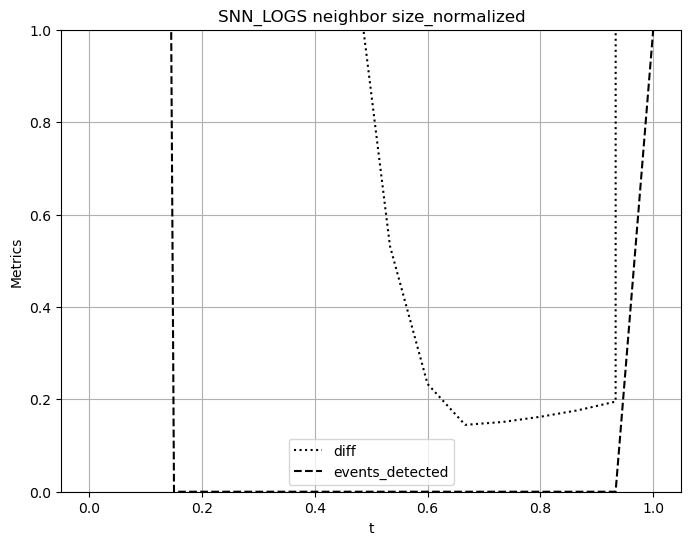

In [22]:

def calculate_metrics(model, model_eps, ratio=0.03):
    metrics = {'S_diff': torch.norm(model.S-model_eps.S).cpu().numpy().item(),
               'X_diff': torch.norm(model.X-model_eps.X).cpu().numpy().item(),
               'events_detected': sum(detect_topk_events(np.abs(model.S.cpu().detach().numpy()), ratio)).item(),
                }
    metrics['diff'] = metrics['S_diff'] + metrics['X_diff']
    return metrics

def run_snn(Y, G, t, eps, grouping, weighing, device, r_hop):
    r_hop = 1; max_iter = 100; err_tol = 1e-5; rho = 1e-3; rho_upd = 1.1
    dtype = torch.float64
    # G_nyc, dropoffs = load_data()
    model = SNN_LOGS(Y, G, lr_modes=[1,2,3,4], graph_modes=[1],
                     device=device, dtype=dtype, verbose=0, r_hop=r_hop,
                     grouping=grouping, weighing=weighing)
    X, S = model([(1-t),(1-t),(1-t),(1-t)], t, max_iter=max_iter, err_tol=err_tol, rho=rho,
               rho_update=rho_upd, rho_update_thr=100)
    model_eps = SNN_LOGS(Y, G, lr_modes=[1,2,3,4], graph_modes=[1],
                     device=device, dtype=dtype, verbose=0, r_hop=r_hop)
    X_eps, S_eps = model_eps([(1-t+eps),(1-t+eps),(1-t+eps),(1-t+eps)], t-eps, max_iter=max_iter, err_tol=err_tol, rho=rho,
               rho_update=rho_upd, rho_update_thr=100)
    metric = calculate_metrics(model, model_eps,ratio = 0.03)
    return metric

start =0
end = 1
num_steps = 100
eps = (end-start)/(num_steps*10)
r_hop = 1
grouping = 'neighbor'
weighing = 'size_normalized'
t_range = list(np.linspace(start+eps, 0.4, 40, endpoint=False))+list(np.linspace(0.4, end, 10, endpoint=True))
metrics = []
futures = []
for i, t in tqdm(enumerate(t_range)):
    # device = f'cuda:{i%4}'
    # futures.append( client.submit(run_snn, dropoffs, G_nyc,  t, eps, grouping, weighing, device, r_hop))
    # if i%4 == 3 or i == num_steps-1:
    #     metrics = metrics + [f.result() for f in futures]
    #     futures = []
    metrics.append(run_snn(dropoffs, G_nyc, t, eps, grouping, weighing, device, r_hop))

metrics_pd = pd.DataFrame(metrics)
fig, axe = plt.subplots(1, 1, figsize=(8, 6))
axe.plot(t_range, metrics_pd['diff'], label='diff', color='k',linestyle=':')
axe.plot(t_range, metrics_pd['events_detected'], label='events_detected', color='k',linestyle='--')
axe.set_ylim([0,1])
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.set_title(f'SNN_LOGS {grouping} {weighing}')
axe.legend()
axe.grid()


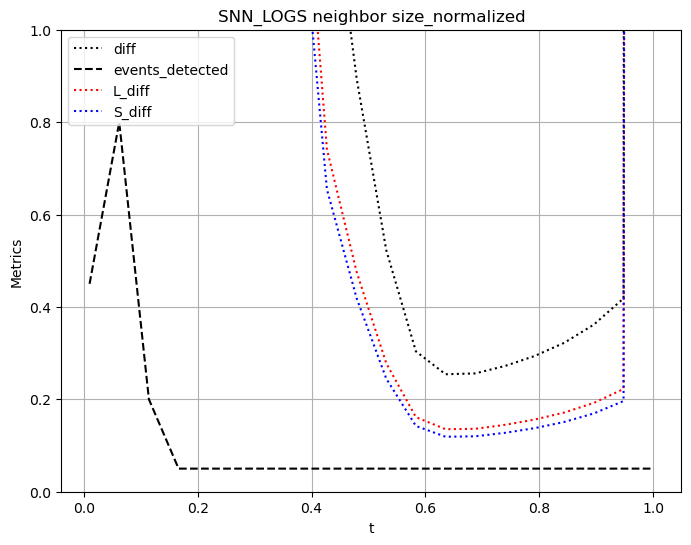

In [14]:
fig, axe = plt.subplots(1, 1, figsize=(8, 6))
axe.plot(t_range, metrics_pd['diff'], label='diff', color='k',linestyle=':')
axe.plot(t_range, metrics_pd['events_detected']/20, label='events_detected', color='k',linestyle='--')
axe.plot(t_range, metrics_pd['X_diff'], label='L_diff', color='r',linestyle=':')
axe.plot(t_range, metrics_pd['S_diff'], label='S_diff', color='b',linestyle=':')
axe.set_ylim([0,1])
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.set_title(f'SNN_LOGS {grouping} {weighing}')
axe.legend()
axe.grid()


In [27]:
def calculate_metrics(model, model_eps, ratio=0.03):
    device = model.device
    metrics = {'S_diff': torch.norm(model.S-model_eps.S).cpu().numpy().item(),
               'X_diff': torch.norm(model.X-model_eps.X).cpu().numpy().item(),
               '#events_detected': sum(detect_topk_events(np.abs(model.S.cpu().detach().numpy()), ratio)),
                }
    metrics['diff'] = metrics['S_diff'] + metrics['X_diff']
    return metrics

t=0.15; r_hop=1; max_iter=500; err_tol=1e-6; rho=1e-2; rho_upd=1.1
model = SNN_LOGS(dropoffs, G_nyc, lr_modes=[1,2,3,4], graph_modes=[1],
                     device=device, dtype=dtype, verbose=2, r_hop=r_hop)
X, S = model([(1-t),(1-t),(1-t),(1-t)], t, max_iter=max_iter, err_tol=err_tol, rho=rho,
               rho_update=rho_upd, rho_update_thr=100)
calculate_metrics(model,model, ratio=0.03)

It-0 	# |r| = 5.0429e+04 	|s| = 1.5211e+03 	 obj = 2.1393e+05
	# |r_x0| = 7.3078e+02 	# |s_x0| = 3.5691e+02 	# rho_x0 = 1.0000e-02
	# |r_x1| = 6.1881e+02 	# |s_x1| = 3.5705e+02 	# rho_x1 = 1.0000e-02
	# |r_x2| = 2.2489e+02 	# |s_x2| = 3.5741e+02 	# rho_x2 = 1.0000e-02
	# |r_x3| = 4.1641e+02 	# |s_x3| = 3.5705e+02 	# rho_x3 = 1.0000e-02
	# |r_v| = 4.7112e+04 	# |s_v| = 4.7112e+02 	# rho_v = 1.0000e-02
	# |r_f| = 1.7954e+04 	# |s_f| = 1.2577e+03 	# rho_f = 1.0000e-02
It-1 	# |r| = 1.1658e+04 	|s| = 2.4696e+02 	 obj = 1.4474e+07
	# |r_x0| = 7.9635e+01 	# |s_x0| = 7.1216e+01 	# rho_x0 = 1.0000e-02
	# |r_x1| = 3.0351e+01 	# |s_x1| = 7.1011e+01 	# rho_x1 = 1.0000e-02
	# |r_x2| = 1.1853e+01 	# |s_x2| = 7.0696e+01 	# rho_x2 = 1.0000e-02
	# |r_x3| = 2.2496e+01 	# |s_x3| = 7.1005e+01 	# rho_x3 = 1.0000e-02
	# |r_v| = 8.4680e+03 	# |s_v| = 8.4680e+01 	# rho_v = 1.0000e-02
	# |r_f| = 8.0127e+03 	# |s_f| = 1.8347e+02 	# rho_f = 1.0000e-02
It-2 	# |r| = 5.1626e+03 	|s| = 6.9415e+01 	 obj = 1.2677e+0

{'S_diff': 0.0, 'X_diff': 0.0, '#events_detected': 6.0, 'diff': 0.0}